In [1]:
# ============================================================
# NutriClass - COMPLETE TRAINING NOTEBOOK 
# ============================================================
# Features: df.info, describe, NaN check, duplicates, boxplot, 
#           one-hot encoder, corr plot, PCA, model comparison, joblib save
# ============================================================

## 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, classification_report,
    precision_recall_fscore_support
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")



In [2]:
## 2. LOAD DATASET
df = pd.read_csv('synthetic_food_dataset_imbalanced.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (31700, 16)


,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [ ]:
## 3. BASIC DATA EXPLORATION 
print("=== DATA INFO ===")
df.info()

print("\n=== DESCRIBE NUMERIC ===")
print(df.describe())

print("\n=== TARGET DISTRIBUTION (IMBALANCE CHECK) ===")
print(df['Food_Name'].value_counts())
print("\nImbalance ratio (max/min):", 
      df['Food_Name'].value_counts().max() / df['Food_Name'].value_counts().min())


=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null 

=== MISSING VALUES CHECK ===
Calories          375
Protein           375
Fat               375
Carbs             375
Sugar             375
Fiber             375
Sodium            375
Cholesterol       375
Glycemic_Index    375
Water_Content     375
Serving_Size      375
dtype: int64

Total missing: 4125


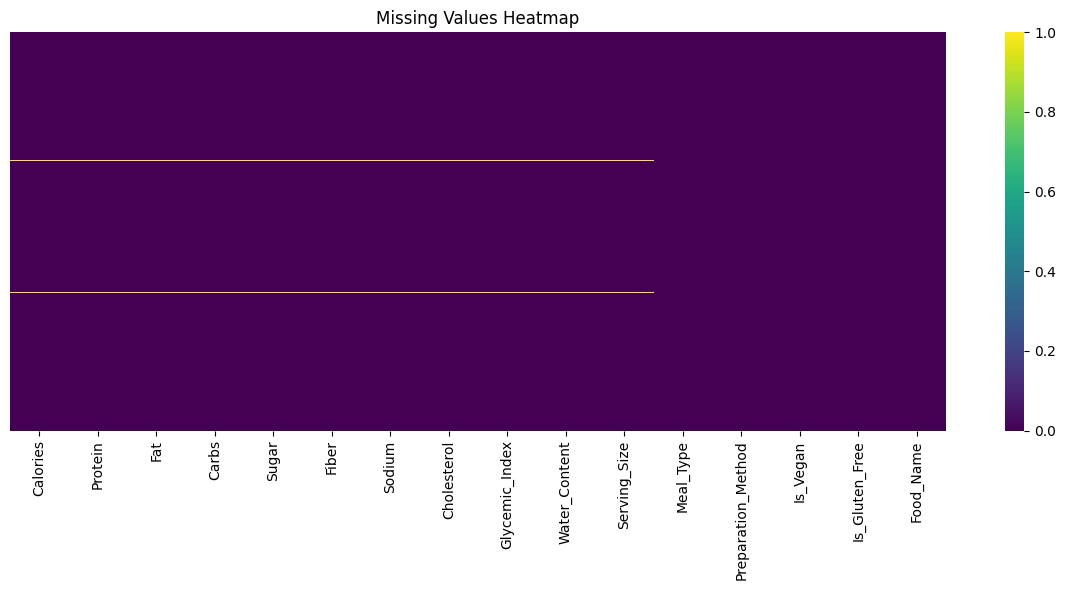

In [ ]:
## 4. NAN CHECK 
print("=== MISSING VALUES CHECK ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum()}")

# Visualize missing data
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
## 5. DUPLICATE CHECK 
print("=== DUPLICATES CHECK ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Dataset size before dedup: {len(df)}")

df_no_dup = df.drop_duplicates()
print(f"Dataset size after dedup: {len(df_no_dup)}")
df = df_no_dup

=== DUPLICATES CHECK ===
Duplicate rows: 313
Dataset size before dedup: 31700
Dataset size after dedup: 31387


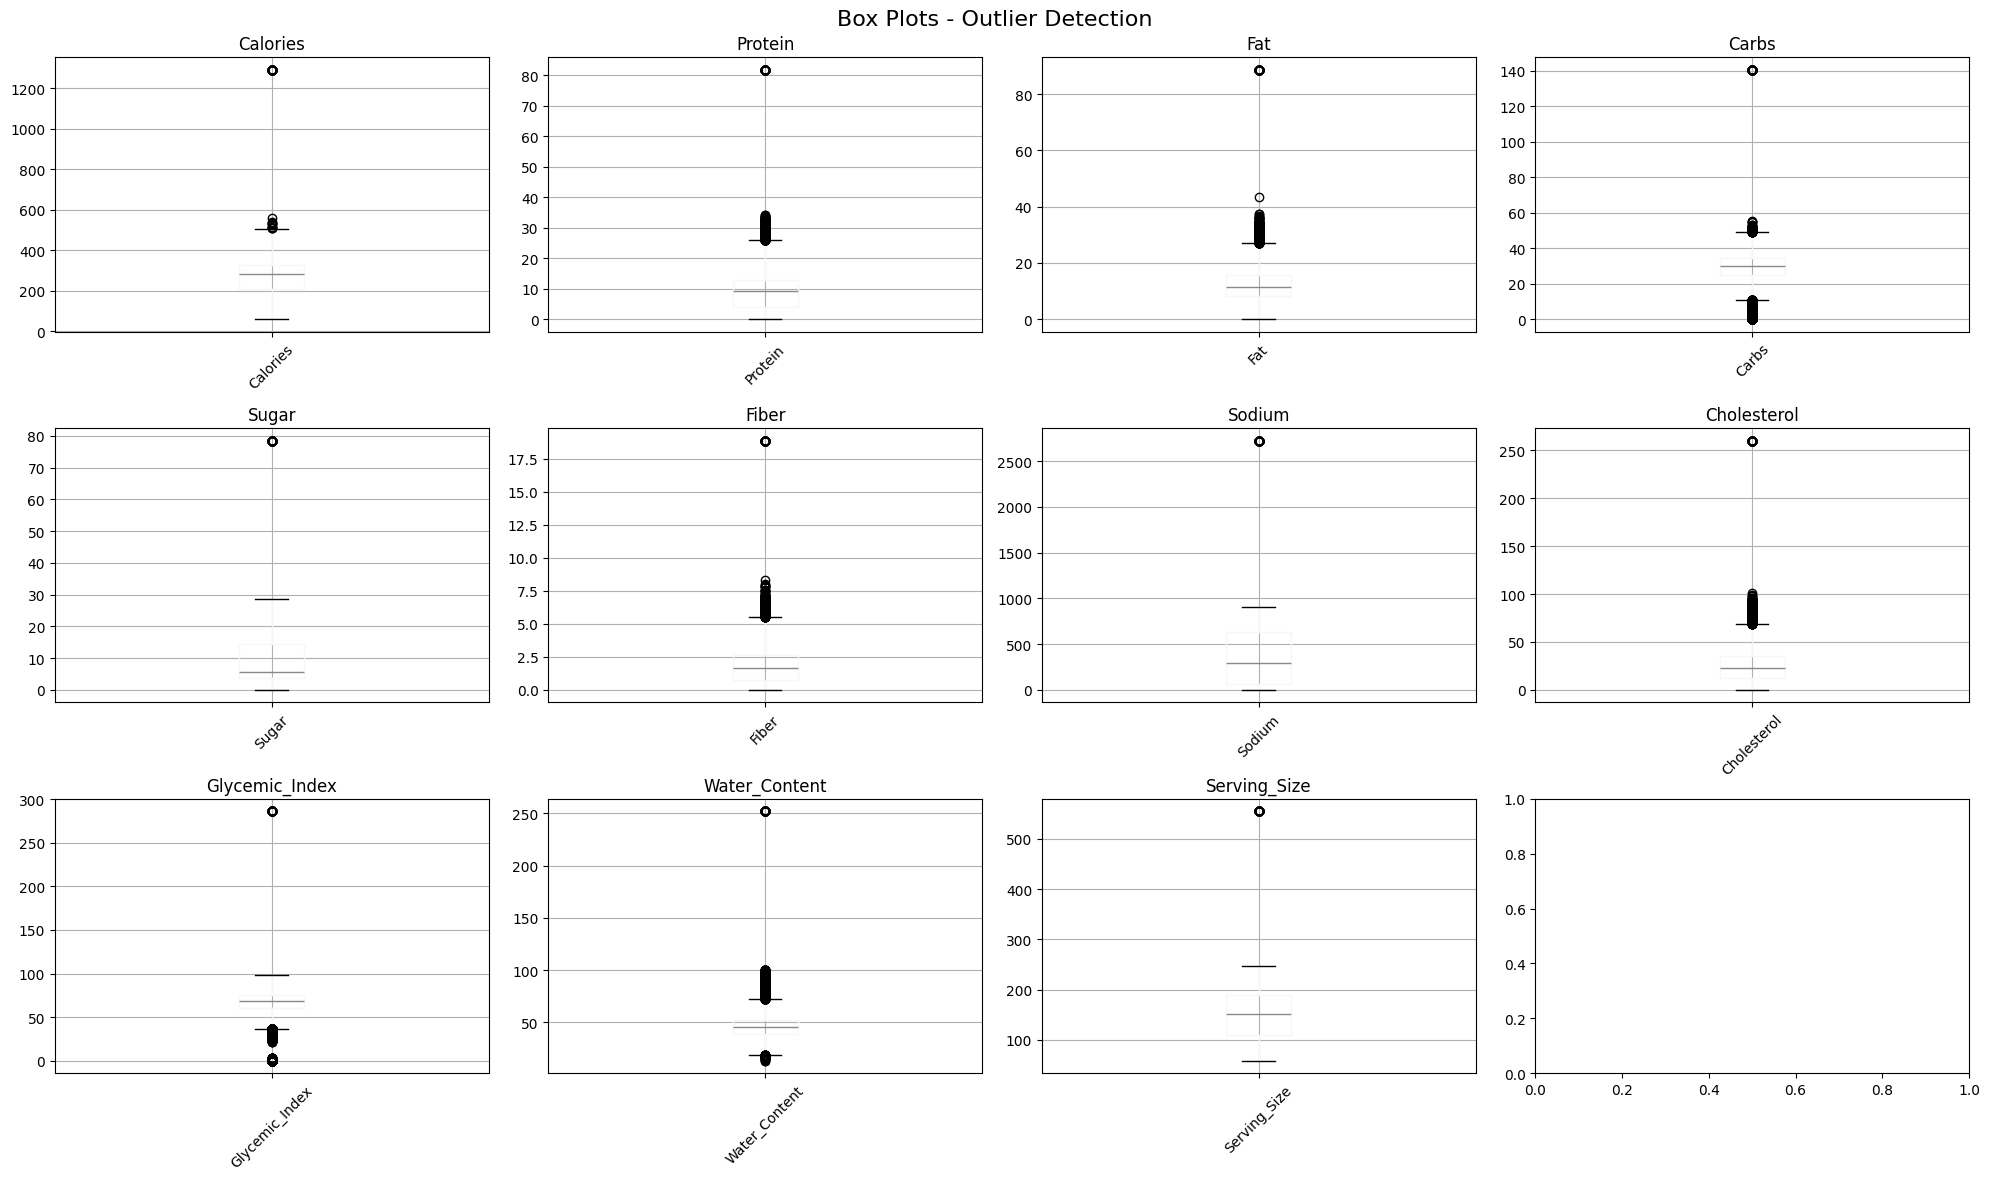

In [ ]:
## 6. BOX PLOTS - OUTLIERS VISUALIZATION 
numeric_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 
                'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Box Plots - Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

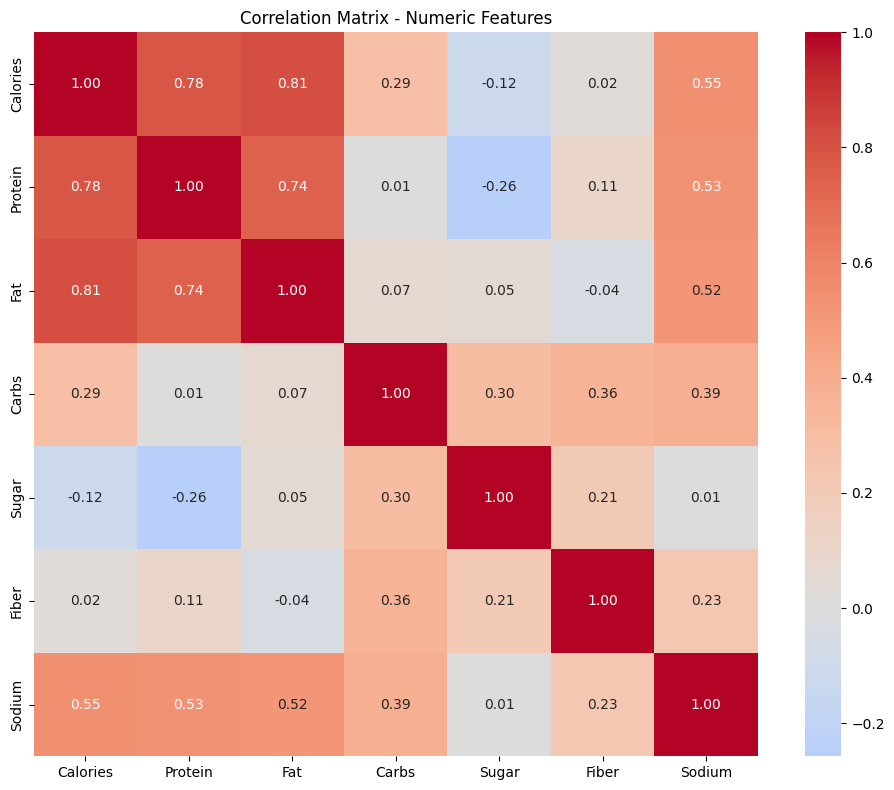

In [ ]:
## 7. CORRELATION PLOT 
# Select numeric columns for correlation
corr_cols = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
## 8. ONE-HOT ENCODING DEMO 
print("=== ONE-HOT ENCODING DEMO ===")
print("Original categorical:")
print(df[['Meal_Type', 'Preparation_Method']].head())

# One-hot encoding
ohe_meal = pd.get_dummies(df['Meal_Type'], prefix='Meal')
ohe_prep = pd.get_dummies(df['Preparation_Method'], prefix='Prep')

print("\nOne-hot encoded (first 5 rows):")
print(pd.concat([ohe_meal.head(), ohe_prep.head()], axis=1))

=== ONE-HOT ENCODING DEMO ===
Original categorical:
  Meal_Type Preparation_Method
0    dinner              fried
1     snack                raw
2     snack                raw
3     lunch              fried
4     snack              baked

One-hot encoded (first 5 rows):
   Meal_breakfast  Meal_dinner  Meal_lunch  Meal_snack  Prep_baked  \
0           False         True       False       False       False   
1           False        False       False        True       False   
2           False        False       False        True       False   
3           False        False        True       False       False   
4           False        False       False        True        True   

   Prep_fried  Prep_grilled  Prep_raw  
0        True         False     False  
1       False         False      True  
2       False         False      True  
3        True         False     False  
4       False         False     False  


In [9]:
## 9. DATA PREPROCESSING PIPELINE
print("=== FULL PREPROCESSING ===")

# Define numeric columns
num_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size'
]

# 1. OUTLIER CAPPING (IQR method)
print("1. Capping outliers...")
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = np.clip(df[col], lower, upper)
    print(f"  {col}: {original_outliers} outliers capped")

# 2. MISSING VALUES
print("\n2. Handling missing values...")
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print("  Missing values imputed with median")

print("\nDataset shape after preprocessing:", df.shape)

=== FULL PREPROCESSING ===
1. Capping outliers...
  Calories: 94 outliers capped
  Protein: 845 outliers capped
  Fat: 784 outliers capped
  Carbs: 2704 outliers capped
  Sugar: 84 outliers capped
  Fiber: 468 outliers capped
  Sodium: 84 outliers capped
  Cholesterol: 2042 outliers capped
  Glycemic_Index: 3094 outliers capped
  Water_Content: 3315 outliers capped
  Serving_Size: 84 outliers capped

2. Handling missing values...
  Missing values imputed with median

Dataset shape after preprocessing: (31387, 16)


In [11]:
## 10. FEATURE ENGINEERING
print("=== FEATURE ENGINEERING ===")

# Label encoding for categoricals (better for tree models)
le_meal = LabelEncoder()
le_prep = LabelEncoder()
le_target = LabelEncoder()

df['Meal_Type_enc'] = le_meal.fit_transform(df['Meal_Type'])
df['Preparation_Method_enc'] = le_prep.fit_transform(df['Preparation_Method'])
df['Is_Vegan_enc'] = df['Is_Vegan'].astype(int)
df['Is_Gluten_Free_enc'] = df['Is_Gluten_Free'].astype(int)

# Final feature list (15 features)
feature_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
    'Meal_Type_enc', 'Preparation_Method_enc', 'Is_Vegan_enc', 'Is_Gluten_Free_enc'
]

X = df[feature_cols]
y = df['Food_Name']
y_enc = le_target.fit_transform(y)

print("Features shape:", X.shape)
print("Target classes:", len(le_target.classes_))
print("Target classes:", le_target.classes_[:10])  # first 10


=== FEATURE ENGINEERING ===
Features shape: (31387, 15)
Target classes: 10
Target classes: ['Apple' 'Banana' 'Burger' 'Donut' 'Ice Cream' 'Pasta' 'Pizza' 'Salad'
 'Steak' 'Sushi']


In [12]:
## 11. TRAIN/TEST SPLIT + SCALING + PCA
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X.shape[1])
print("PCA components (95% variance):", X_train_pca.shape[1])
print("Train shape:", X_train_pca.shape)
print("Test shape:", X_test_pca.shape)

Original features: 15
PCA components (95% variance): 9
Train shape: (25109, 9)
Test shape: (6278, 9)


In [13]:
## 12. MODEL TRAINING & COMPARISON
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
model_objects = {}
best_model = None
best_name = ""
best_acc = 0.0

print("Training 7 models...\n")
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    model_objects[name] = model
    
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision_macro': precision_macro,
        'Recall_macro': recall_macro,
        'F1_macro': f1_macro,
        'CV_5fold': cv_scores.mean()
    })
    
    print(f"{name}: {acc:.3f} accuracy, {cv_scores.mean():.3f} CV")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(f"\n🏆 BEST MODEL: {best_name} ({best_acc:.3f})")
results_df

Training 7 models...

Logistic Regression: 0.990 accuracy, 0.987 CV
Decision Tree: 0.980 accuracy, 0.978 CV
Random Forest: 0.984 accuracy, 0.983 CV
KNN: 0.987 accuracy, 0.986 CV
SVM: 0.991 accuracy, 0.989 CV
XGBoost: 0.988 accuracy, 0.987 CV
Gradient Boosting: 0.987 accuracy, 0.986 CV

🏆 BEST MODEL: SVM (0.991)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,CV_5fold
4,SVM,0.990602,0.992479,0.992218,0.992337,0.989366
0,Logistic Regression,0.990443,0.990900,0.990876,0.990876,0.987455
5,XGBoost,0.987894,0.989609,0.989708,0.989651,0.986817
3,KNN,0.986779,0.988670,0.988034,0.988334,0.986021
6,Gradient Boosting,0.986620,0.987024,0.987103,0.987041,0.985862
2,Random Forest,0.984231,0.985114,0.984933,0.985008,0.982954
1,Decision Tree,0.979771,0.978676,0.978500,0.978566,0.977578


=== SVM DETAILED REPORT ===
              precision    recall  f1-score   support

       Apple       0.99      0.99      0.99       297
      Banana       0.99      0.99      0.99       239
      Burger       0.99      0.97      0.98       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.98      0.99      0.98      1183
       Salad       1.00      0.99      1.00       199
       Steak       1.00      1.00      1.00       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



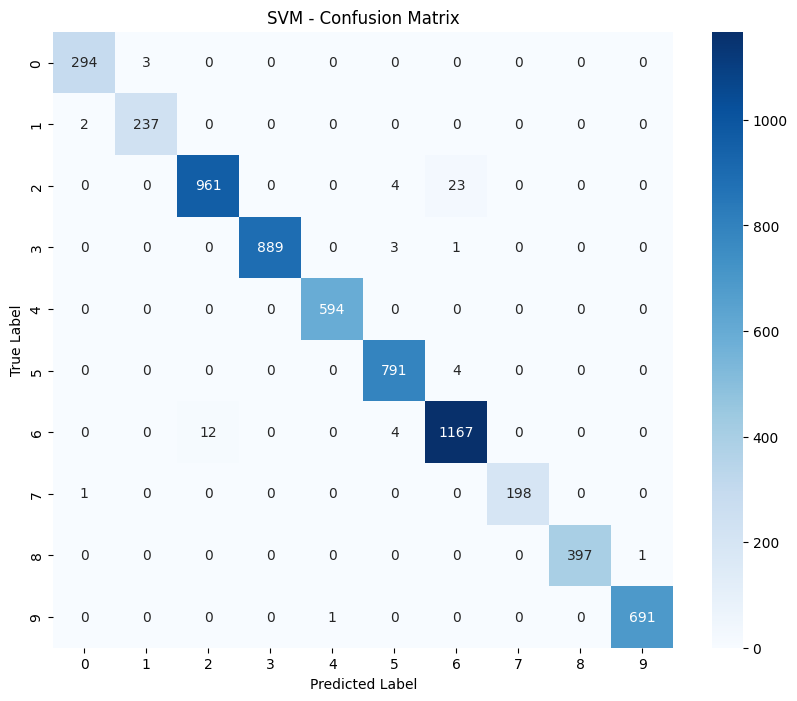

In [14]:
## 13. BEST MODEL EVALUATION
print(f"=== {best_name} DETAILED REPORT ===")
y_best_pred = best_model.predict(X_test_pca)
print(classification_report(y_test, y_best_pred, target_names=le_target.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_name} - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [15]:
## 14. SAVE TRAINED ARTIFACTS WITH JOBLIB
print("=== SAVING ARTIFACTS ===")

joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca, 'pca.joblib')
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(le_meal, 'le_meal.joblib')
joblib.dump(le_prep, 'le_prep.joblib')
joblib.dump(le_target, 'le_target.joblib')
joblib.dump(feature_cols, 'feature_cols.joblib')

print("✅ ALL FILES SAVED:")
print("- scaler.joblib")
print("- pca.joblib") 
print("- best_model.joblib")
print("- le_meal.joblib")
print("- le_prep.joblib")
print("- le_target.joblib")
print("- feature_cols.joblib")

print("\n📱 Streamlit app.py can now load these for FAST predictions!")


=== SAVING ARTIFACTS ===
✅ ALL FILES SAVED:
- scaler.joblib
- pca.joblib
- best_model.joblib
- le_meal.joblib
- le_prep.joblib
- le_target.joblib
- feature_cols.joblib

📱 Streamlit app.py can now load these for FAST predictions!
